In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import gtda
# Homology toolboxes
import gudhi as gd
from gtda.homology import VietorisRipsPersistence, SparseRipsPersistence
import gudhi.hera as gh

# Dataset generation
from sklearn.datasets import load_diabetes

#import tadasets

# Visualization
#from mpl_toolkits.mplot3d import Axes3D
import networkx as nx

from gtda.plotting import plot_point_cloud

# Magic commands
%config Completer.use_jedi=False


In [8]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from matplotlib import pyplot 

In [6]:
import pandas as pd

# 0. Preprocessing of the point cloud - Subsampling {-}

Before start trying to reduce or simplify our simpl. complex, when building the comples out of a point cloud, there are some quick functions we can run at basically no cost for the persistence/bar code. 


```gudhi.sparsify_point_set(point_cloud, min_squared_dist=0)```
This function just delete points closer than min_squared_dist. For a lot of datasets involving data consumption or voice calls, using this method even with min_squared_dist=0 will save quite a lot of time, deleting all points that have the same coordinates (in particular near to the origin). 


```gudhi.choose_n_farthest_points(point_cloud, nb_points, starting_point)```
We get a subsample of size nb_points by a greedy strategy adding the farthest point from the current one. If no starting point passed, it just chooses one randomly. 


Another way of subsampling is just to randomly take $n$ points, which can also be done with Gudhi but also easy to do it with numpy. 

In another notebook I computed the distances between the persistence diagrams of a point cloud before and after *point* sparsification for different values. It could be seen that it works just find and do not affect much to homology. 

# 1. Collapses {-}

## 1.1 Minimal theory {-}

*my take from https://www.maths.ed.ac.uk/~v1ranick/papers/barmak2.pdf*

Let $X$ a finite topological space. For a point $x\in X$, we define the minimal open set $U_x$ as the intersection of all open sets that contain $x$. The minimal sets for every point $x$ constitue a basis, which we call *minimal basis* of $X$. Now, we can define a preorder on $X$ by $x\le y$ if $x\in U_y$.


With the preorder, $X$ is now a finite preordered set, which "corresponds" to a $T_0$ space (the antisymmetry of a finite preorder corresponds to  the $T_0$ separation axiom). A topological space is a $T_0$ space if for any pair of points in $X$ there exists an open set containing one and only one of them. $T_0$ are in correspondece with finite partially ordered sets, named posets. A $T_0 with the ordering can be represented with its Hasse diagram.

Definitions: 

- **Chain in a poset:** subset of elements that are pairwise comparable.
- **Antichain in a poset:** subset of non-comparable elements.
- **Up-beat point:** point with in-degree = 1 in Hasse diagram.
- **Down-beat point:** point with out-degree = 1 in Hasse diagram.
- **Minimal finite space:** space with no (up and down)-beat points.

Removing beat points do not affect the homotopy of the space. Removing a beat point $x$ is a *strong deformation retract* ($X \backslash \{x)\}$). The core of a space is a strong deformation retract which is a minimal finite space.

Finally, we can associate a simplicial complex $K(X)$ of a finite $T_0$-space $X$ by identifying the simplices as the non-empty chains of $X$. 

-----
##### Example 

$X = \{a, b, c, d\}$ with open sets:
$\tau = \{ \{\emptyset \},\{a,b,c,d\}, \{b,d\}, \{c\}, \{d\}, \{b,c,d\},\{c,d\}\}$

so: 

$U_a = \{a,b,c,d\}$

$U_b =\{a,b,c,d\} \cap \{b,d\} \cap \{b,c,d\} = \{b,d\}$

$U_c = \{c\}$

$U_d = \{d\}$

These minimal open sets form the minimal basis of $X$. We can also check the order:

$a \geq b, c, d$

$b \geq d$

With this, we can treat it as a $T_0$-space and easily build its Hasse diagram:

``
a
|  \
b   c
|
d``

*It's actually a digraph, imagine every edge is pointing downwards)*

All points but a are beat points.

We look now at the chains in order to build its associated simplicial complex:
$a-b-d$ is a chain and thus forms the 2-simplex $\{a,b,c\}$ (along the 0- and 1-simplices in it). The other non-empty chain is $a-c$, and thus it will form a 1-simplex $\{a, c\}$.

## 1.2 Elementary collapses (Def 4.2.5.) {-}

It can happen that a $T_0$-space $X$ is not contractible, *i.e.,* it does not have any beat points, but its associated complex is. For this, it is defined the notion of *weak beat points* of $X$. $x$ is a weak point if $U_x\backslash \{x\}$ or its closure $F_x\backslash \{x\}$ is contractible, that is, its core is a point. The former is a *down weak point* while the latter is an *up weak point*. 

For $Y = X\backslash \{x\}$, if $x$ is a weak point, we say that $Y$ collapses to $Y$ by an elementary collapse.



___________________________________
....*To complete*

*more stuff needed: simplicial collapse, strong collapse... In any case, from strong collapses one "delete" dominated vertex. The edge_collapse goes beyond and delete directly edges (both papers where these methods were proposed are signed by Bossonnat as a first author and are implemented in C++)

Edge collapse: https://drops.dagstuhl.de/opus/volltexte/2020/12177/pdf/LIPIcs-SoCG-2020-19.pdf \
Strong collapse (vertices): https://arxiv.org/pdf/1809.10945.pdf

By building the nerves of each Collapse  complex with the set of vertices $V$ being the set of its maximal simplices. (This isthe one I had in mind. Section 3 of https://arxiv.org/pdf/0907.2954.pdf 

Also interesting: https://arxiv.org/pdf/1905.07329.pdf

# 2. Gudhi ```collapse_edges``` method {-}

Implemented from (Section 5): https://drops.dagstuhl.de/opus/volltexte/2020/12177/pdf/LIPIcs-SoCG-2020-19.pdf

**tl;dr**: quick summary in the end




### Dataset {-}

In [4]:
# Wir nutzen den öffentlichen diabetes Datensatz
data_diabetes = load_diabetes()
type(data_diabetes)


sklearn.utils.Bunch

In [5]:
X = data_diabetes.data
Y = data_diabetes.target

In [7]:
dfX = pd.DataFrame(data_diabetes.data, columns=data_diabetes.feature_names)

In [10]:
pyplot.rcParams['figure.figsize'] = [20, 20]

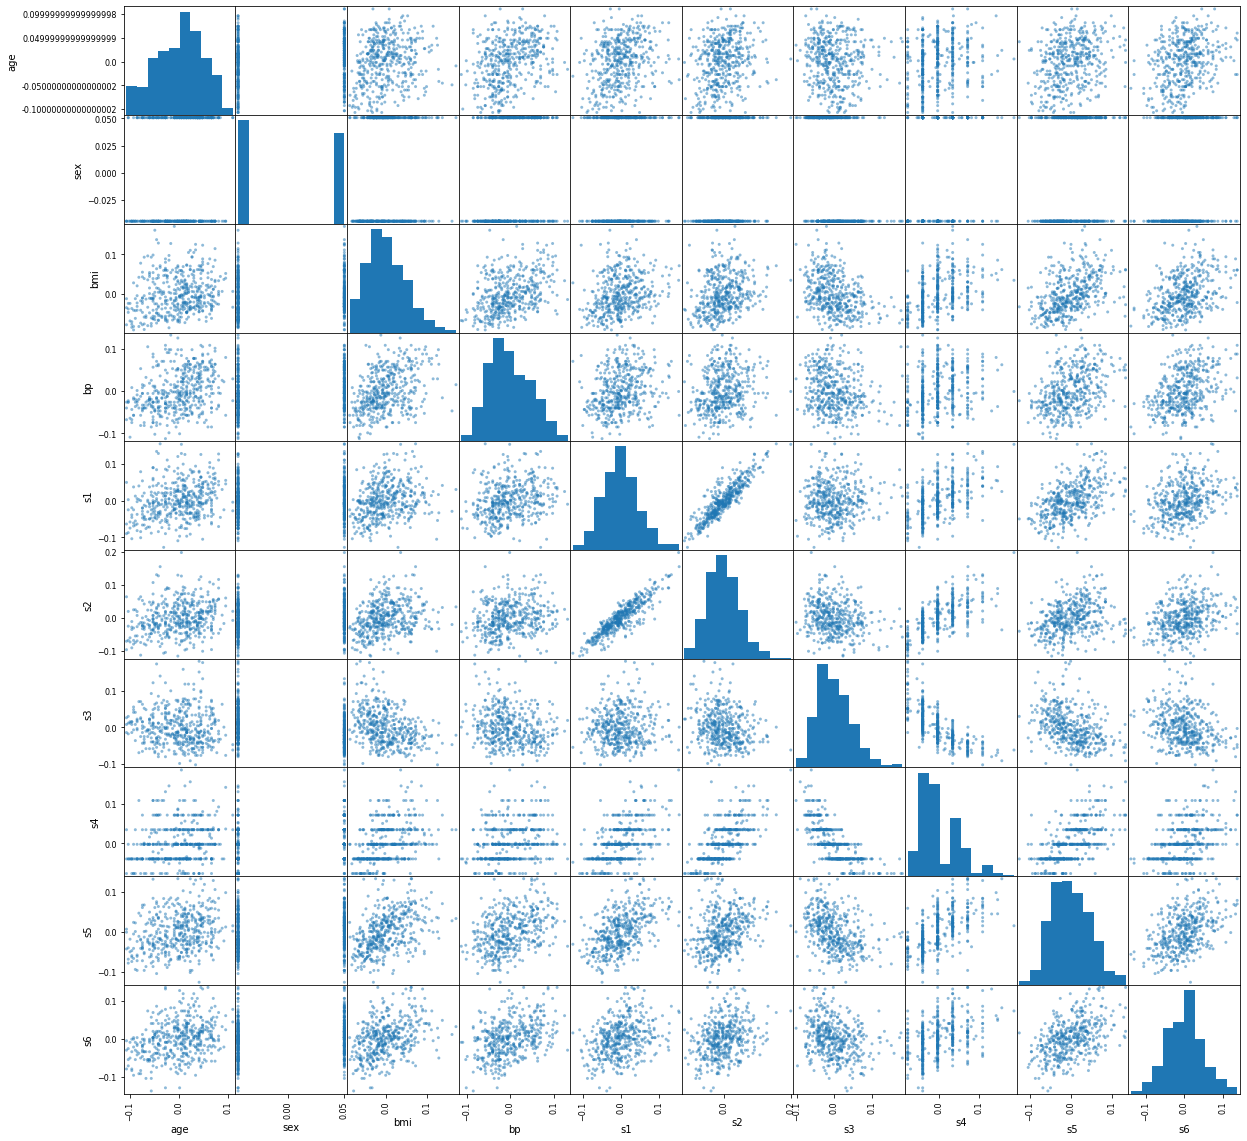

In [11]:
scatter_matrix(dfX)
pyplot.show()

### Original Diabetes Datenset Rips Komplex Berechnung

In [12]:
# Build the VR complex
print('Build VR complex')
VR = gd.RipsComplex(X, max_edge_length=20, sparse=0.2)
%time diabetes_stree = VR.create_simplex_tree(max_dimension=3)

Build VR complex
CPU times: user 4min 4s, sys: 12.3 s, total: 4min 16s
Wall time: 4min 16s


In [21]:
# Berechnung der Persistenz. Wir wählen IZ_2 als Körper für die Koeffizienten der Einfachheit halber
%time persistence_diabetes = diabetes_stree.persistence(homology_coeff_field=2)

CPU times: user 20min 55s, sys: 6.74 s, total: 21min 1s
Wall time: 21min 1s


In [22]:
print('\nAnzahl der Knoten (0-Simplexe):  ', diabetes_stree.num_vertices())
print('Dimension des Simplizialkomplexes: ', diabetes_stree.dimension())


Anzahl der Knoten (0-Simplexe):   442
Dimension des Simplizialkomplexes:  3


In [23]:
# Um die Wirkung des Edge Collapsing Verfahrens demonstrieren zu können, zählen wir Simplexe der Dimensionen 1, 2 und 3
skeleton_diabetes = []
sum_skeleton = []

for i in range(4):
    skeleton_diabetes.insert(i, diabetes_stree.get_skeleton(i))
    sum_skeleton.insert(i, sum(1 for _ in skeleton_diabetes[i]))
    
for i in range (3):
    nn = sum_skeleton[i+1] - sum_skeleton[i]
    print('Anzahl der {}-Simplexe: {}'.format(i+1, f'{nn:,}'))

Anzahl der 1-Simplexe: 97,439
Anzahl der 2-Simplexe: 14,275,889
Anzahl der 3-Simplexe: 1,563,568,456


In [24]:
print('Gesamtzahl aller Simplexe:', f'{torus_st.num_simplices():,}')

Gesamtzahl aller Simplexe: 1,577,942,226


### VR filtration with collapse_edges {-}

Since it assumes the simplex is a 1-skeleton, we build the 1-dimensional Rips complex and then expand (following the suggestion in the documentation)

In [27]:
# VR Komplex, nicht sparse, max. Dimension 1
VR_ce = gd.RipsComplex(X, max_edge_length=20)
%time diabetes_stree_collapsed = VR_ce.create_simplex_tree(max_dimension=1)

CPU times: user 14.3 ms, sys: 0 ns, total: 14.3 ms
Wall time: 13.8 ms


In [28]:
%time VR_ce = diabetes_stree_collapsed.collapse_edges()

CPU times: user 4.47 s, sys: 12 µs, total: 4.47 s
Wall time: 4.47 s


In [29]:
%time diabetes_stree_collapsed.expansion(3)

CPU times: user 249 ms, sys: 28 ms, total: 277 ms
Wall time: 276 ms


In [31]:
# Und zum Vergleich die Persistenz nach Collapseund Expansion
%time persistence_diabetes_collapsed = diabetes_stree_collapsed.persistence(homology_coeff_field=2)

CPU times: user 5.68 s, sys: 56 ms, total: 5.74 s
Wall time: 5.73 s


In [32]:
print('\nAnzahl der Knoten (0-Simplexe):  ', diabetes_stree_collapsed.num_vertices())
print('Dimension des Simplizialkomplexes: ', diabetes_stree_collapsed.dimension())


Anzahl der Knoten (0-Simplexe):   442
Dimension des Simplizialkomplexes:  3


In [34]:
# Hier nun das deutlich kleinere Datenset nach Edge Collaps
skeleton_diabetes_collapsed = []
sum_skeleton_collapsed = []

for i in range(4):
    skeleton_diabetes_collapsed.insert(i, diabetes_stree_collapsed.get_skeleton(i))
    sum_skeleton_collapsed.insert(i, sum(1 for _ in skeleton_diabetes_collapsed[i]))
    
for i in range (3):
    nn = sum_skeleton_collapsed[i+1] - sum_skeleton_collapsed[i]
    print('Anzahl der {}-Simplexe: {}'.format(i+1, f'{nn:,}'))


Anzahl der 1-Simplexe: 17,750
Anzahl der 2-Simplexe: 412,297
Anzahl der 3-Simplexe: 6,581,595


In [ ]:
pyplot.rcParams['figure.figsize'] = [20, 20]

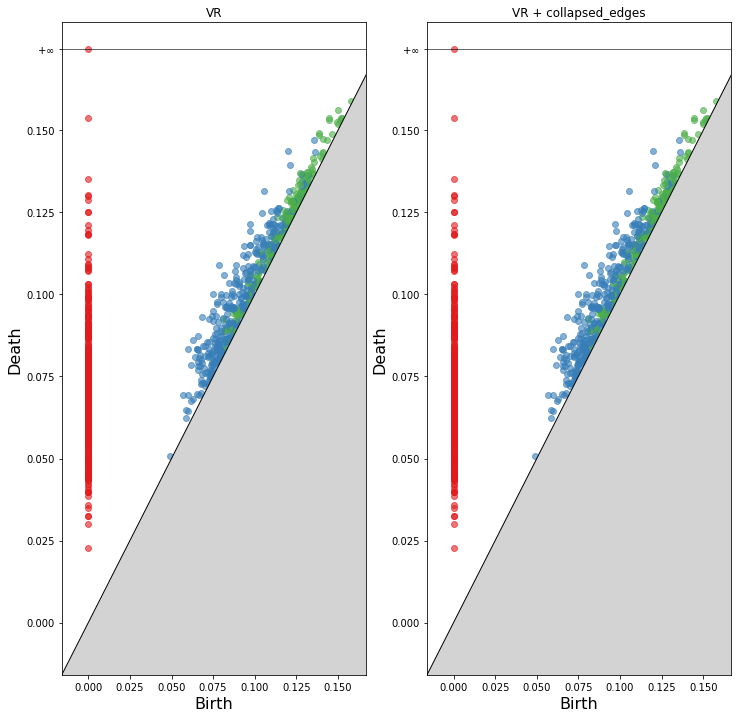

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(12, 12))
titles = ['VR', 'VR + collapsed_edges']

diag = [persistence_diabetes, persistence_diabetes_collapsed]

coordinates = [0, 1]

for coor, tl, d in zip(coordinates, titles, diag): 
    # Persistence diagram
    
    gd.plot_persistence_diagram(d, axes=ax[coor])
    ax[coor].set_title(tl)


In [40]:
vrd = [[point[1] for point in persistence_diabetes]][0]
ced = [[point[1] for point in persistence_diabetes_collapsed]][0]

# Print distances between diagrams
print('Bottleneck distances with respect to VR \
      \nCollapsing Edges: %s ' %
     (gh.bottleneck_distance(vrd, ced)
     ))


print('\n\nWasserstein distances with respect to VR \
      \nCollapsing Edges: %s ' %
     (gh.wasserstein_distance(vrd, ced)
     ))

Bottleneck distances with respect to VR       
Collapsing Edges: 0.0 


Wasserstein distances with respect to VR       
Collapsing Edges: 0.0 
